In [72]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
from jax.scipy.linalg import expm
import matplotlib.pyplot as plt



In [73]:
dt = 0.01
num_trajectories = 20
rho = 0.1
lr = 1e-3
epochs = 50000
N_ensemble = 30                  
dim_state = 2  

In [74]:
#Setup

A = jnp.array([
    [1.0, -4.0],
    [4.0, -7.0]
])


t_eval = jnp.arange(0, 2.0, dt)


key = jax.random.PRNGKey(127)
key, subkey = jax.random.split(key)
y0s = jax.random.uniform(subkey, (num_trajectories, 2), minval=-2.0, maxval=2.0)

def get_trajectory(y0):
    return jax.vmap(lambda t: expm(A * t) @ y0)(t_eval)

trajectories = jax.vmap(get_trajectory)(y0s)


# Use the first 4 trajectories for training
train_trajectories = trajectories[:16, :, :]
# Use the last (5th) trajectory for testing
test_trajectory = trajectories[16:20, :, :]

# Prepare training pairs (inputs and targets) from the 4 training trajectories
X_train = train_trajectories[:, :-1, :].reshape(-1, 2)
Y_train = train_trajectories[:, 1:, :].reshape(-1, 2)

# Prepare testing pairs from the 1 testing trajectory
X_test = test_trajectory[:, :-1, :].reshape(-1, 2)
Y_test = test_trajectory[:, 1:, :].reshape(-1, 2)


#generating noisy trajectories
sigmas = jnp.std(trajectories, axis=(0, 1))

noise_std = rho * sigmas  
noise_std_broadcast = noise_std[jnp.newaxis, jnp.newaxis, :]
key, subkey = jax.random.split(key)
normal_noise = jax.random.normal(subkey, shape=trajectories.shape)

epsilon = normal_noise * noise_std

noisy_trajectories = trajectories + epsilon


# Use the first 16 trajectories for training
train_noisy = noisy_trajectories[:16, :, :]
# Use the last trajectory for testing
test_noisy = noisy_trajectories[16:20, :, :]

# Prepare training pairs (inputs and targets) from the 4 training trajectories
X_train_noisy = train_noisy[:, :-1, :].reshape(-1, 2)
Y_train_noisy = train_noisy[:, 1:, :].reshape(-1, 2)

# Prepare testing pairs from the 1 testing trajectory
X_test_noisy = test_noisy[:, :-1, :].reshape(-1, 2)
Y_test_noisy = test_noisy[:, 1:, :].reshape(-1, 2)

optimizer = optax.adam(lr)


In [75]:
class FlowMapNN(eqx.Module):
    dt: float
    linear1: eqx.nn.Linear
    linear2: eqx.nn.Linear
    linear3: eqx.nn.Linear
    def __init__(self, dt, key):
        self.dt = dt
        key1, key2, key3 = jax.random.split(key, 3)
        self.linear1 = eqx.nn.Linear(2, 32, key=key1)
        self.linear2 = eqx.nn.Linear(32, 32, key=key2)
        self.linear3 = eqx.nn.Linear(32, 2, key=key3)

    def __call__(self, y):
        h = jax.nn.tanh(self.linear1(y))
        h = jax.nn.tanh(self.linear2(h))
        dy = self.linear3(h)
        return y + self.dt * dy

def compute_loss(model, x, y_target):
    
    batched_forward = jax.vmap(model)
    y_pred = batched_forward(x)
    return jnp.mean((y_pred - y_target) ** 2)

@eqx.filter_jit
def train_step(model, opt_state, x, y_target):
    
    loss, grads = eqx.filter_value_and_grad(compute_loss)(model, x, y_target)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return model, opt_state, loss

Epoch    0 | MSE Loss: 0.000519
Epoch  100 | MSE Loss: 0.000174
Epoch  200 | MSE Loss: 0.000058
Epoch  300 | MSE Loss: 0.000037
Epoch  400 | MSE Loss: 0.000023
Epoch  500 | MSE Loss: 0.000013
Epoch  600 | MSE Loss: 0.000008
Epoch  700 | MSE Loss: 0.000006
Epoch  800 | MSE Loss: 0.000004
Epoch  900 | MSE Loss: 0.000003
Epoch 1000 | MSE Loss: 0.000002
Epoch 1100 | MSE Loss: 0.000002
Epoch 1200 | MSE Loss: 0.000001
Epoch 1300 | MSE Loss: 0.000001
Epoch 1400 | MSE Loss: 0.000001
Epoch 1500 | MSE Loss: 0.000001
Epoch 1600 | MSE Loss: 0.000001
Epoch 1700 | MSE Loss: 0.000000
Epoch 1800 | MSE Loss: 0.000000
Epoch 1900 | MSE Loss: 0.000000
Epoch 2000 | MSE Loss: 0.000000
Epoch 2100 | MSE Loss: 0.000000
Epoch 2200 | MSE Loss: 0.000000
Epoch 2300 | MSE Loss: 0.000000
Epoch 2400 | MSE Loss: 0.000000
Epoch 2500 | MSE Loss: 0.000000
Epoch 2600 | MSE Loss: 0.000000
Epoch 2700 | MSE Loss: 0.000000
Epoch 2800 | MSE Loss: 0.000000
Epoch 2900 | MSE Loss: 0.000000
Epoch 3000 | MSE Loss: 0.000000
Epoch 31

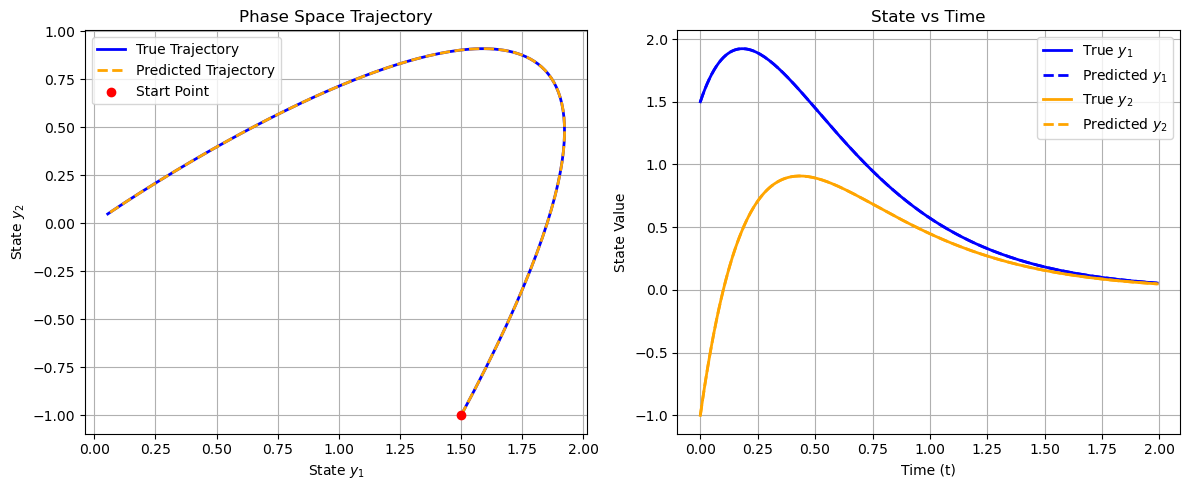

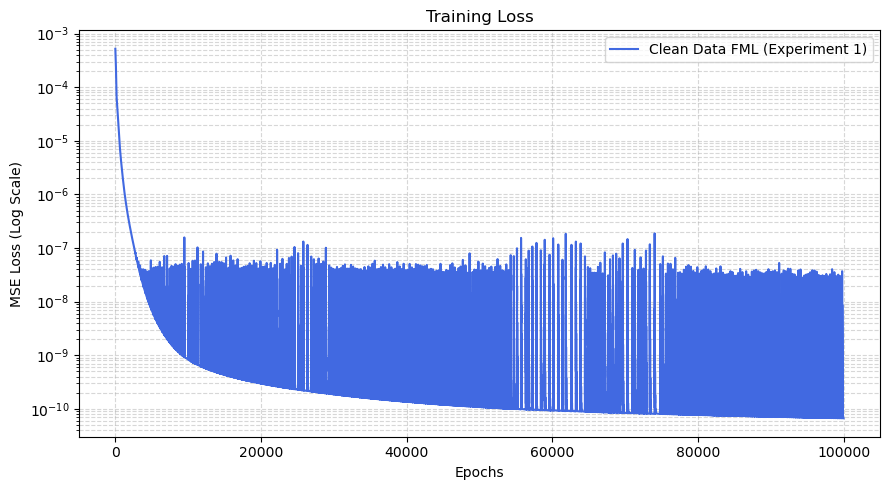

Full-Trajectory Rollout Test MSE Loss: 0.000012


In [76]:
#Experiment 1: FML with Clean Data

key, subkey = jax.random.split(key)
model_clean = FlowMapNN(dt=dt, key=subkey)

opt_state_clean = optimizer.init(eqx.filter(model_clean, eqx.is_array))

losses_clean = []
for epoch in range(epochs):
    model_clean, opt_state_clean, loss = train_step(model_clean, opt_state_clean, X_train, Y_train)
    losses_clean.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss:.6f}")

print(f"Final Epoch {epochs} | MSE Loss: {loss:.6f}")


test_y0 = jnp.array([1.5, -1.0])
exact_y_next = expm(A * dt) @ test_y0
predicted_y_next = model_clean(test_y0) 

print("\n--- Validation on new state ---")
print(f"Initial State:    {test_y0}")
print(f"Exact Next State: {exact_y_next}")
print(f"Predicted State:  {predicted_y_next}")


true_test_traj = get_trajectory(test_y0)


def rollout(model, y0, num_steps):
    
    def step(y, _):
        y_next = model(y)
        return y_next, y_next
    _, traj = jax.lax.scan(step, y0, jnp.arange(num_steps - 1))
    
    
    return jnp.vstack([y0, traj])


pred_test_traj = rollout(model_clean, test_y0, len(t_eval))


fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(true_test_traj[:, 0], true_test_traj[:, 1], label="True Trajectory", color="blue", linewidth=2)
ax[0].plot(pred_test_traj[:, 0], pred_test_traj[:, 1], label="Predicted Trajectory", color="orange", linestyle="--", linewidth=2)
ax[0].scatter(test_y0[0], test_y0[1], color="red", zorder=5, label="Start Point")
ax[0].set_xlabel("State $y_1$")
ax[0].set_ylabel("State $y_2$")
ax[0].set_title("Phase Space Trajectory")
ax[0].legend()
ax[0].grid(True)


ax[1].plot(t_eval, true_test_traj[:, 0], label="True $y_1$", color="blue", linewidth=2)
ax[1].plot(t_eval, pred_test_traj[:, 0], label="Predicted $y_1$", color="blue", linestyle="--", linewidth=2)
ax[1].plot(t_eval, true_test_traj[:, 1], label="True $y_2$", color="orange", linewidth=2)
ax[1].plot(t_eval, pred_test_traj[:, 1], label="Predicted $y_2$", color="orange", linestyle="--", linewidth=2)
ax[1].set_xlabel("Time (t)")
ax[1].set_ylabel("State Value")
ax[1].set_title("State vs Time")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()

plt.figure(figsize=(9, 5))

# Plot the tracked losses
plt.plot(losses_clean, label="Clean Data FML (Experiment 1)", color="royalblue", linewidth=1.5)

plt.xlabel("Epochs")
plt.ylabel("MSE Loss (Log Scale)")
plt.title("Training Loss")

plt.yscale("log") 
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# 1. Get the starting point of your 5th (test) trajectory
test_y0_trajectory = trajectories[19, 0, :] 

# 2. Get the true full trajectory for the 5th sequence
true_test_traj = trajectories[19, :, :]

# 3. Generate the predicted rollout from that starting point
pred_test_traj = rollout(model_clean, test_y0_trajectory, len(t_eval))

# 4. Compute the full trajectory MSE
full_trajectory_loss = jnp.mean((pred_test_traj - true_test_traj) ** 2)
print(f"Full-Trajectory Rollout Test MSE Loss: {full_trajectory_loss:.6f}")


Epoch    0 | MSE Loss: 0.008310
Epoch  100 | MSE Loss: 0.007856
Epoch  200 | MSE Loss: 0.007467
Epoch  300 | MSE Loss: 0.007158
Epoch  400 | MSE Loss: 0.006851
Epoch  500 | MSE Loss: 0.006689
Epoch  600 | MSE Loss: 0.006610
Epoch  700 | MSE Loss: 0.006567
Epoch  800 | MSE Loss: 0.006538
Epoch  900 | MSE Loss: 0.006510
Epoch 1000 | MSE Loss: 0.006490
Epoch 1100 | MSE Loss: 0.006472
Epoch 1200 | MSE Loss: 0.006448
Epoch 1300 | MSE Loss: 0.006431
Epoch 1400 | MSE Loss: 0.006416
Epoch 1500 | MSE Loss: 0.006402
Epoch 1600 | MSE Loss: 0.006391
Epoch 1700 | MSE Loss: 0.006381
Epoch 1800 | MSE Loss: 0.006372
Epoch 1900 | MSE Loss: 0.006364
Epoch 2000 | MSE Loss: 0.006356
Epoch 2100 | MSE Loss: 0.006348
Epoch 2200 | MSE Loss: 0.006340
Epoch 2300 | MSE Loss: 0.006331
Epoch 2400 | MSE Loss: 0.006322
Epoch 2500 | MSE Loss: 0.006311
Epoch 2600 | MSE Loss: 0.006300
Epoch 2700 | MSE Loss: 0.006289
Epoch 2800 | MSE Loss: 0.006279
Epoch 2900 | MSE Loss: 0.006270
Epoch 3000 | MSE Loss: 0.006261
Epoch 31

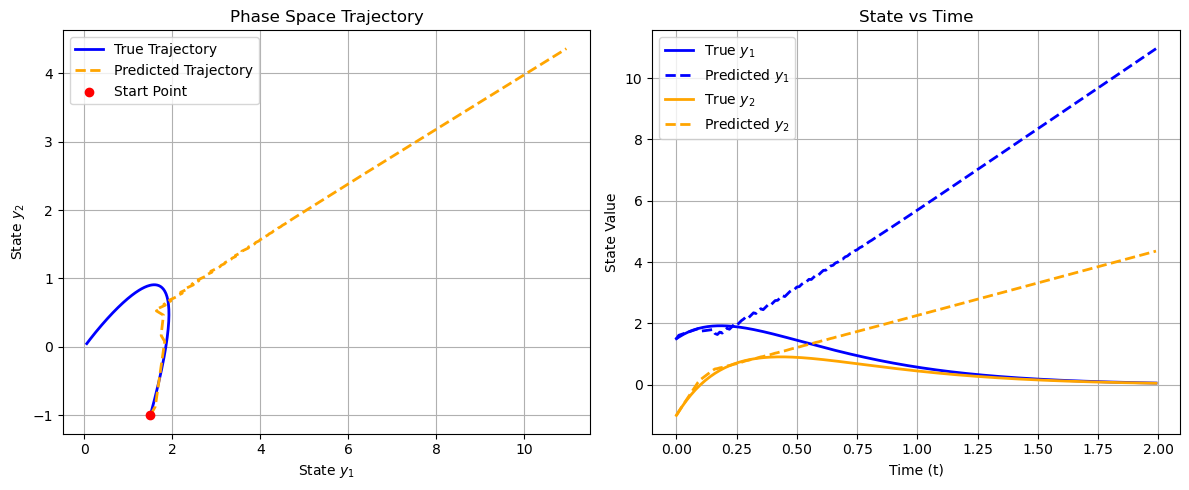

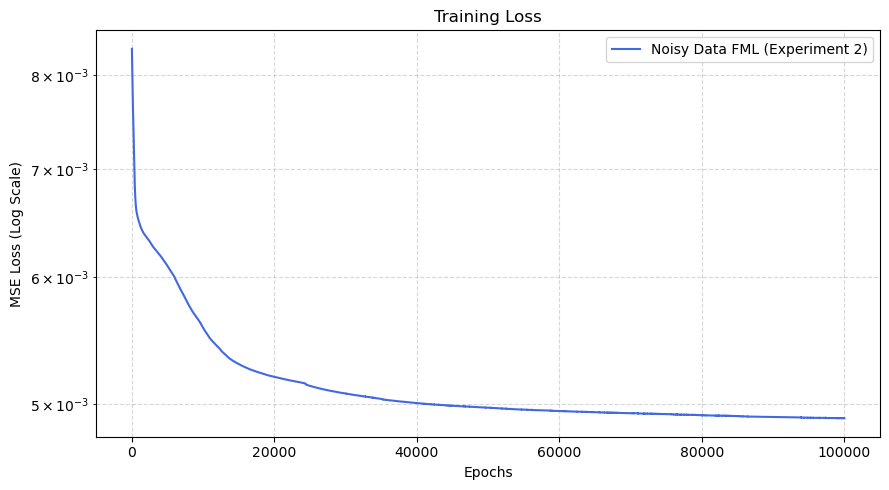

Full-Trajectory Rollout Test MSE Loss: 1.002402


In [77]:
#Experiment 2: FML with noisy data

model_noisy = FlowMapNN(dt=dt, key=subkey)
opt_state_noisy = optimizer.init(eqx.filter(model_noisy, eqx.is_array))
losses_noisy = []
for epoch in range(epochs):
    model_noisy, opt_state_noisy, loss = train_step(model_noisy, opt_state_noisy, X_train_noisy, Y_train_noisy)
    losses_noisy.append(float(loss))
    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss:.6f}")

print(f"Final Epoch {epochs} | MSE Loss: {loss:.6f}")


test_y0 = jnp.array([1.5, -1.0])
exact_y_next = expm(A * dt) @ test_y0
predicted_y_next = model_noisy(test_y0) 

print("\n--- Validation on new state ---")
print(f"Initial State:    {test_y0}")
print(f"Exact Next State: {exact_y_next}")
print(f"Predicted State:  {predicted_y_next}")


test_y0 = jnp.array([1.5, -1.0])


true_test_traj = get_trajectory(test_y0)


def rollout(model, y0, num_steps):
    
    def step(y, _):
        y_next = model(y)
        return y_next, y_next
    _, traj = jax.lax.scan(step, y0, jnp.arange(num_steps - 1))
    
    
    return jnp.vstack([y0, traj])


pred_test_traj_noisy = rollout(model_noisy, test_y0, len(t_eval))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))


ax[0].plot(true_test_traj[:, 0], true_test_traj[:, 1], label="True Trajectory", color="blue", linewidth=2)
ax[0].plot(pred_test_traj_noisy[:, 0], pred_test_traj_noisy[:, 1], label="Predicted Trajectory", color="orange", linestyle="--", linewidth=2)
ax[0].scatter(test_y0[0], test_y0[1], color="red", zorder=5, label="Start Point")
ax[0].set_xlabel("State $y_1$")
ax[0].set_ylabel("State $y_2$")
ax[0].set_title("Phase Space Trajectory")
ax[0].legend()
ax[0].grid(True)


ax[1].plot(t_eval, true_test_traj[:, 0], label="True $y_1$", color="blue", linewidth=2)
ax[1].plot(t_eval, pred_test_traj_noisy[:, 0], label="Predicted $y_1$", color="blue", linestyle="--", linewidth=2)
ax[1].plot(t_eval, true_test_traj[:, 1], label="True $y_2$", color="orange", linewidth=2)
ax[1].plot(t_eval, pred_test_traj_noisy[:, 1], label="Predicted $y_2$", color="orange", linestyle="--", linewidth=2)
ax[1].set_xlabel("Time (t)")
ax[1].set_ylabel("State Value")
ax[1].set_title("State vs Time")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()


plt.figure(figsize=(9, 5))
plt.plot(losses_noisy, label="Noisy Data FML (Experiment 2)", color="royalblue", linewidth=1.5)
plt.xlabel("Epochs")
plt.ylabel("MSE Loss (Log Scale)")
plt.title("Training Loss")
plt.yscale("log") 
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


# 1. Get the starting point of your 5th (test) trajectory
test_y0_trajectory = trajectories[19, 0, :] 

# 2. Get the true full trajectory for the 5th sequence
true_test_traj = trajectories[19, :, :]

# 3. Generate the predicted rollout from that starting point
pred_test_traj_noisy = rollout(model_noisy, test_y0_trajectory, len(t_eval))

# 4. Compute the full trajectory MSE
full_trajectory_loss = jnp.mean((pred_test_traj_noisy - true_test_traj) ** 2)
print(f"Full-Trajectory Rollout Test MSE Loss: {full_trajectory_loss:.6f}")


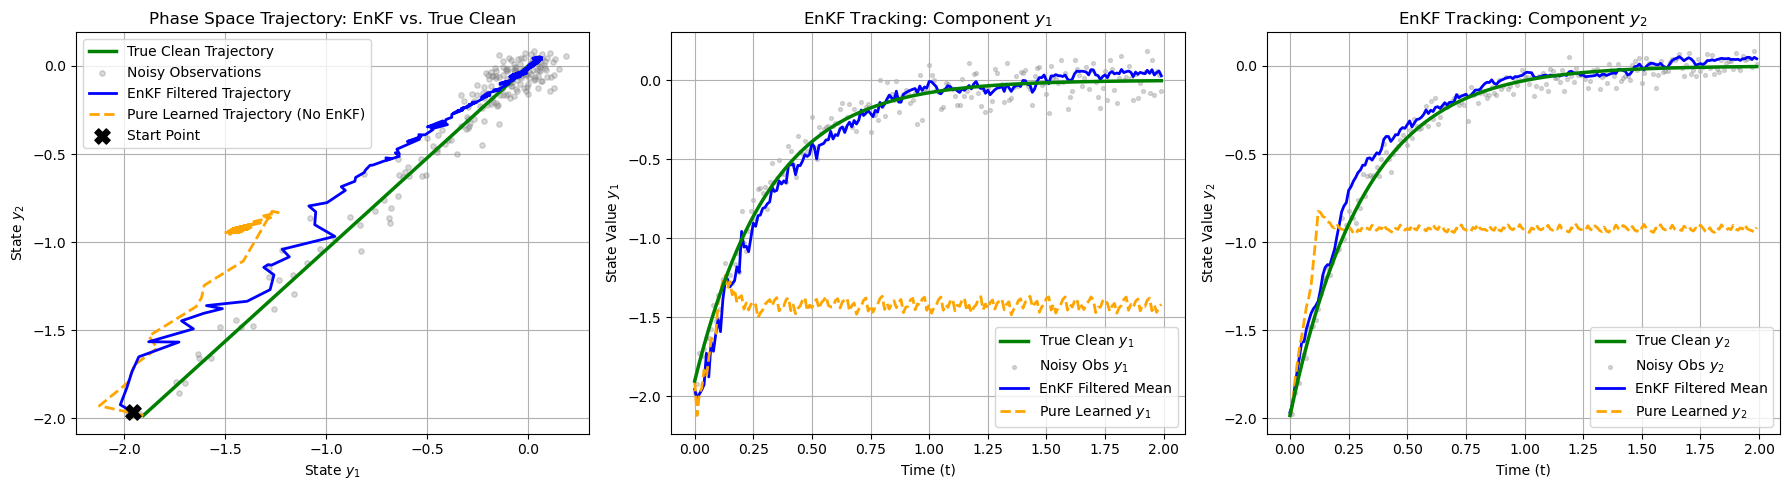

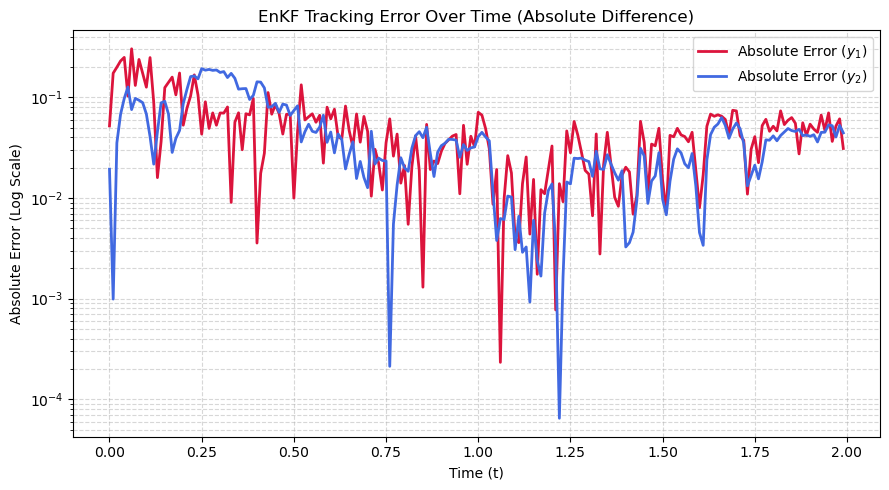

In [80]:

#Experiment 3: Noisy FML Model as Forecast using EnKF
                  
num_steps = len(t_eval)

# Observation Operator H (Assuming we observe all states directly)
H = jnp.eye(dim_state)           

# Measurement Noise Covariance Matrix R
# Using the same noise variance applied to the test data earlier
R = jnp.diag((rho * sigmas) ** 2)  

# 1. Initialize the Ensemble
# We seed the initial ensemble around the first noisy observation of our test trajectory
test_traj_noisy = noisy_trajectories[19, :, :] # (time_steps, 2)
y0_initial_guess = test_traj_noisy[0, :]

key, subkey = jax.random.split(key)
# Sample an initial ensemble distributed around the starting observation
ensemble = y0_initial_guess + jax.random.multivariate_normal(
    subkey, jnp.zeros(dim_state), R, shape=(N_ensemble,)
) # Shape: (N_ensemble, 2)

# Vectorized forecast function for the ensemble
batched_forecast = jax.vmap(model_noisy)

# Arrays to store the tracked history
enkf_mean_history = []
enkf_cov_history = []

# --- MAIN DATA ASSIMILATION LOOP ---
for k in range(num_steps):
    # --- 1. FORECAST STEP (Time Propagation using your Neural Network) ---
    if k > 0:
        # Pass the entire ensemble through the FlowMapNN to forecast the next time step
        ensemble = batched_forecast(ensemble)
        
    # --- 2. ANALYSIS STEP (Data Assimilation using Noisy Observations) ---
    # Current noisy observation at time step k
    y_obs = test_traj_noisy[k, :] 
    
    # Compute the ensemble mean and sample covariance matrix
    ens_mean = jnp.mean(ensemble, axis=0)
    X_deviations = ensemble - ens_mean
    # Sample Covariance Pf = (1 / (N - 1)) * X_deviations^T * X_deviations
    Pf = (X_deviations.T @ X_deviations) / (N_ensemble - 1)
    
    # Generate perturbed observations (Crucial for classic EnKF consistency)
    key, subkey = jax.random.split(key)
    perturbed_obs = y_obs + jax.random.multivariate_normal(
        subkey, jnp.zeros(dim_state), R, shape=(N_ensemble,)
    ) # Shape: (N_ensemble, 2)
    
    # Compute Kalman Gain: K = Pf * H^T * (H * Pf * H^T + R)^(-1)
    # Since H is an identity matrix here, this simplifies to: Pf @ inv(Pf + R)
    innovation_cov = Pf + R
    K = Pf @ jnp.linalg.inv(innovation_cov)
    
    # Update each ensemble member: x_analysis = x_forecast + K * (y_perturbed - H * x_forecast)
    # Transposing handles batch multiplication cleanly
    ensemble_predictions = ensemble @ H.T
    ensemble = ensemble + (perturbed_obs - ensemble_predictions) @ K.T
    
    # Store the filtered metrics for analysis
    post_mean = jnp.mean(ensemble, axis=0)
    post_cov = (ensemble - post_mean).T @ (ensemble - post_mean) / (N_ensemble - 1)
    
    enkf_mean_history.append(post_mean)
    enkf_cov_history.append(post_cov)

# Convert results back to JAX arrays
enkf_mean_history = jnp.array(enkf_mean_history)
enkf_cov_history = jnp.array(enkf_cov_history)

learned_traj = rollout(model_noisy, true_test_traj[0, :], len(t_eval))

enkf_std = jnp.sqrt(jnp.array([jnp.diag(c) for c in enkf_cov_history]))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# --- PLOT 1: State 1 vs Time ---

ax[0].plot(true_test_traj[:, 0], true_test_traj[:, 1], 
         label="True Clean Trajectory", color="green", linewidth=2.5, zorder=3)
ax[0].scatter(test_traj_noisy[:, 0], test_traj_noisy[:, 1], 
            label="Noisy Observations", color="gray", alpha=0.3, s=15, zorder=2)
ax[0].plot(enkf_mean_history[:, 0], enkf_mean_history[:, 1], 
         label="EnKF Filtered Trajectory", color="blue", linestyle="-", linewidth=2, zorder=4)
ax[0].plot(learned_traj[:, 0], learned_traj[:, 1], 
         label="Pure Learned Trajectory (No EnKF)", color="orange", linestyle="--", linewidth=2, zorder=3)
ax[0].scatter(enkf_mean_history[0, 0], enkf_mean_history[0, 1], 
            color="black", marker="X", s=120, zorder=5, label="Start Point")
ax[0].set_xlabel("State $y_1$")
ax[0].set_ylabel("State $y_2$")
ax[0].set_title("Phase Space Trajectory: EnKF vs. True Clean")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(t_eval, true_test_traj[:, 0], label="True Clean $y_1$", color="green", linewidth=2.5, zorder=3)
ax[1].scatter(t_eval, test_traj_noisy[:, 0], color="gray", alpha=0.3, s=8, label="Noisy Obs $y_1$")
ax[1].plot(t_eval, enkf_mean_history[:, 0], label="EnKF Filtered Mean", color="blue", linestyle="-", linewidth=2)
ax[1].plot(t_eval, learned_traj[:, 0], label="Pure Learned $y_1$", color="orange", linestyle="--", linewidth=2)
ax[1].set_xlabel("Time (t)")
ax[1].set_ylabel("State Value $y_1$")
ax[1].set_title("EnKF Tracking: Component $y_1$")
ax[1].legend()
ax[1].grid(True)

# --- PLOT 2: State 2 vs Time ---
ax[2].plot(t_eval, true_test_traj[:, 1], label="True Clean $y_2$", color="green", linewidth=2.5, zorder=3)
ax[2].scatter(t_eval, test_traj_noisy[:, 1], color="gray", alpha=0.3, s=8, label="Noisy Obs $y_2$")
ax[2].plot(t_eval, enkf_mean_history[:, 1], label="EnKF Filtered Mean", color="blue", linestyle="-", linewidth=2)
ax[2].plot(t_eval, learned_traj[:, 1], label="Pure Learned $y_2$", color="orange", linestyle="--", linewidth=2)
ax[2].set_xlabel("Time (t)")
ax[2].set_ylabel("State Value $y_2$")
ax[2].set_title("EnKF Tracking: Component $y_2$")
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()

abs_error_y1 = jnp.abs(true_test_traj[:, 0] - enkf_mean_history[:, 0])
abs_error_y2 = jnp.abs(true_test_traj[:, 1] - enkf_mean_history[:, 1])
plt.figure(figsize=(9, 5))

# Plot component-wise absolute differences
plt.semilogy(t_eval, abs_error_y1, label=r"Absolute Error ($y_1$)", color="crimson", linewidth=2)
plt.semilogy(t_eval, abs_error_y2, label=r"Absolute Error ($y_2$)", color="royalblue", linewidth=2)
plt.xlabel("Time (t)")
plt.ylabel("Absolute Error (Log Scale)")
plt.title("EnKF Tracking Error Over Time (Absolute Difference)")
plt.grid(True, which="both", linestyle="--", alpha=0.5) # 'both' ensures major and minor gridlines show up on log scale
plt.legend()
plt.tight_layout()
plt.show()





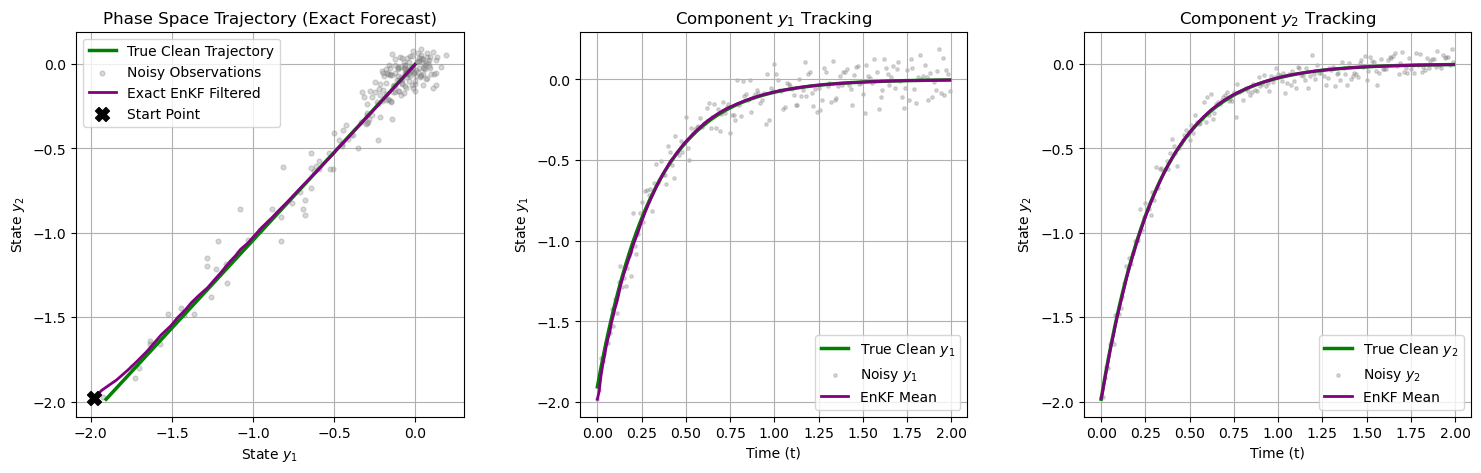

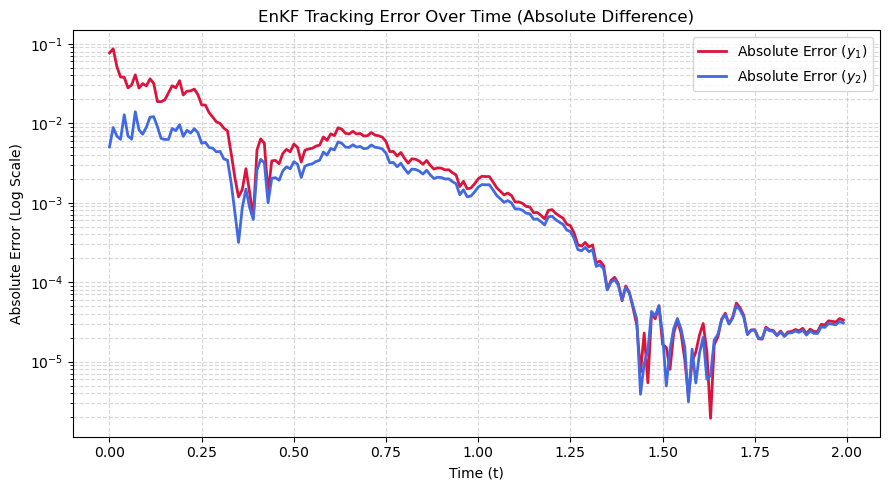

In [82]:


# Experiment 4: Exact Model as Forecast applying EnKF
               
num_steps = len(t_eval)

# Observation Operator H (Assuming we observe all states directly)
H = jnp.eye(dim_state)           

# Measurement Noise Covariance Matrix R
R = jnp.diag((rho * sigmas) ** 2)  

# Exact Discrete-Time State Transition Matrix \Phi = e^(A * dt)
Phi = expm(A * dt)

# 1. Initialize the Ensemble around the first noisy observation
test_traj_noisy = noisy_trajectories[19, :, :] # (time_steps, 2)
y0_initial_guess = test_traj_noisy[0, :]

key, subkey = jax.random.split(key)
ensemble = y0_initial_guess + jax.random.multivariate_normal(
    subkey, jnp.zeros(dim_state), R, shape=(N_ensemble,)
) # Shape: (N_ensemble, 2)

# --- Define the Exact Forecast Step ---
# For the exact system, x_{k+1} = \Phi @ x_k
# We vectorize this over the ensemble using jax.vmap
def exact_forecast_fn(ens_member):
    return Phi @ ens_member

batched_exact_forecast = jax.vmap(exact_forecast_fn)

# Arrays to store tracking history
enkf_exact_mean_history = []
enkf_exact_cov_history = []

# --- MAIN DATA ASSIMILATION LOOP ---
for k in range(num_steps):
    # --- 1. FORECAST STEP (Time Propagation using Exact Matrix Exponential) ---
    if k > 0:
        # Move the entire ensemble one step forward using the true physics
        ensemble = batched_exact_forecast(ensemble)
        
    # --- 2. ANALYSIS STEP (Data Assimilation using Noisy Observations) ---
    y_obs = test_traj_noisy[k, :] 
    
    # Compute ensemble background mean and sample covariance matrix (Pf)
    ens_mean = jnp.mean(ensemble, axis=0)
    X_deviations = ensemble - ens_mean
    Pf = (X_deviations.T @ X_deviations) / (N_ensemble - 1)
    
    # Generate perturbed observations for filter consistency
    key, subkey = jax.random.split(key)
    perturbed_obs = y_obs + jax.random.multivariate_normal(
        subkey, jnp.zeros(dim_state), R, shape=(N_ensemble,)
    ) # Shape: (N_ensemble, 2)
    
    # Compute Kalman Gain: K = Pf @ H^T @ inv(H @ Pf @ H^T + R)
    innovation_cov = Pf + R
    K = Pf @ jnp.linalg.inv(innovation_cov)
    
    # Update ensemble members based on the incoming noisy data point
    ensemble_predictions = ensemble @ H.T
    ensemble = ensemble + (perturbed_obs - ensemble_predictions) @ K.T
    
    # Calculate and store the updated (posterior) mean and covariance
    post_mean = jnp.mean(ensemble, axis=0)
    post_cov = (ensemble - post_mean).T @ (ensemble - post_mean) / (N_ensemble - 1)
    
    enkf_exact_mean_history.append(post_mean)
    enkf_exact_cov_history.append(post_cov)

# Convert results back to JAX arrays
enkf_exact_mean_history = jnp.array(enkf_exact_mean_history)
enkf_exact_cov_history = jnp.array(enkf_exact_cov_history)



true_test_traj_clean = trajectories[19, :, :]
enkf_exact_std = jnp.sqrt(jnp.array([jnp.diag(c) for c in enkf_exact_cov_history]))

fig = plt.figure(figsize=(18, 5))
grid = plt.GridSpec(1, 3, wspace=0.3)

# --- PLOT 1: Phase Space Trajectory ---
ax0 = fig.add_subplot(grid[0, 0])
ax0.plot(true_test_traj_clean[:, 0], true_test_traj_clean[:, 1], 
         label="True Clean Trajectory", color="green", linewidth=2.5, zorder=3)
ax0.scatter(test_traj_noisy[:, 0], test_traj_noisy[:, 1], 
            label="Noisy Observations", color="gray", alpha=0.3, s=12, zorder=2)
ax0.plot(enkf_exact_mean_history[:, 0], enkf_exact_mean_history[:, 1], 
         label="Exact EnKF Filtered", color="purple", linestyle="-", linewidth=2, zorder=4)
ax0.scatter(enkf_exact_mean_history[0, 0], enkf_exact_mean_history[0, 1], 
            color="black", marker="X", s=100, zorder=5, label="Start Point")
ax0.set_xlabel("State $y_1$")
ax0.set_ylabel("State $y_2$")
ax0.set_title("Phase Space Trajectory (Exact Forecast)")
ax0.legend()
ax0.grid(True)

# --- PLOT 2: State 1 vs Time ---
ax1 = fig.add_subplot(grid[0, 1])
ax1.plot(t_eval, true_test_traj_clean[:, 0], label="True Clean $y_1$", color="green", linewidth=2.5)
ax1.scatter(t_eval, test_traj_noisy[:, 0], color="gray", alpha=0.3, s=6, label="Noisy $y_1$")
ax1.plot(t_eval, enkf_exact_mean_history[:, 0], label="EnKF Mean", color="purple", linewidth=2)

ax1.set_xlabel("Time (t)")
ax1.set_ylabel("State $y_1$")
ax1.set_title("Component $y_1$ Tracking")
ax1.legend()
ax1.grid(True)

# --- PLOT 3: State 2 vs Time ---
ax2 = fig.add_subplot(grid[0, 2])
ax2.plot(t_eval, true_test_traj_clean[:, 1], label="True Clean $y_2$", color="green", linewidth=2.5)
ax2.scatter(t_eval, test_traj_noisy[:, 1], color="gray", alpha=0.3, s=6, label="Noisy $y_2$")
ax2.plot(t_eval, enkf_exact_mean_history[:, 1], label="EnKF Mean", color="purple", linewidth=2)

ax2.set_xlabel("Time (t)")
ax2.set_ylabel("State $y_2$")
ax2.set_title("Component $y_2$ Tracking")
ax2.legend()
ax2.grid(True)

plt.show()


abs_error_y1 = jnp.abs(true_test_traj_clean[:, 0] - enkf_exact_mean_history[:, 0])
abs_error_y2 = jnp.abs(true_test_traj_clean[:, 1] - enkf_exact_mean_history[:, 1])
plt.figure(figsize=(9, 5))

# Plot component-wise absolute differences
plt.semilogy(t_eval, abs_error_y1, label=r"Absolute Error ($y_1$)", color="crimson", linewidth=2)
plt.semilogy(t_eval, abs_error_y2, label=r"Absolute Error ($y_2$)", color="royalblue", linewidth=2)
plt.xlabel("Time (t)")
plt.ylabel("Absolute Error (Log Scale)")
plt.title("EnKF Tracking Error Over Time (Absolute Difference)")
plt.grid(True, which="both", linestyle="--", alpha=0.5) # 'both' ensures major and minor gridlines show up on log scale
plt.legend()
plt.tight_layout()
plt.show()